## Customer Churn Prediction


In [1]:
# Standard imports 
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter 

#Sklearn 
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV 
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer 
from sklearn.pipeline import Pipeline 
from sklearn.impute import SimpleImputer 

#Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC 
from sklearn.naive_bayes import GaussianNB

#Metrics & utilities 
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import joblib 
import warnings 
warnings.filterwarnings("ignore")

In [2]:
# Display settings 
sns.set_theme(style='whitegrid' , palette='muted', font_scale=1.05)
pd.set_option('display.max_column' , 200)

In [3]:
# Load datasets(adjust)

df = pd.read_csv("customer_data.csv")
print("Shape:", df.shape)
df.head()


Shape: (10000, 12)


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
# Initial Inspection 

#Info & summary 
display(df.info())
display(df.describe(include='all').T)

# Missing values
print("\nMissing values per column:")
print(df.isnull().sum)

# Target distribution
print("n\Churn value counts:")
print(df['churn'].value_counts(normalize=False))
print("\nChurn proportion:")
print(df['churn'].value_counts(normalize=True))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,10000.0,NaN,NaN,NaN,15690940.5694,71936.186123,15565701.0,15628528.25,15690738.0,15753233.75,15815690.0
credit_score,10000.0,NaN,NaN,NaN,650.5288,96.653299,350.0,584.0,652.0,718.0,850.0
country,10000,3,France,5014,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,10000,2,Male,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,10000.0,NaN,NaN,NaN,38.9218,10.487806,18.0,32.0,37.0,44.0,92.0
tenure,10000.0,NaN,NaN,NaN,5.0128,2.892174,0.0,3.0,5.0,7.0,10.0
balance,10000.0,NaN,NaN,NaN,76485.889288,62397.405202,0.0,0.0,97198.54,127644.24,250898.09
products_number,10000.0,NaN,NaN,NaN,1.5302,0.581654,1.0,1.0,1.0,2.0,4.0
credit_card,10000.0,NaN,NaN,NaN,0.7055,0.45584,0.0,0.0,1.0,1.0,1.0
active_member,10000.0,NaN,NaN,NaN,0.5151,0.499797,0.0,0.0,1.0,1.0,1.0



Missing values per column:
<bound method DataFrame.sum of       customer_id  credit_score  country  gender    age  tenure  balance  \
0           False         False    False   False  False   False    False   
1           False         False    False   False  False   False    False   
2           False         False    False   False  False   False    False   
3           False         False    False   False  False   False    False   
4           False         False    False   False  False   False    False   
...           ...           ...      ...     ...    ...     ...      ...   
9995        False         False    False   False  False   False    False   
9996        False         False    False   False  False   False    False   
9997        False         False    False   False  False   False    False   
9998        False         False    False   False  False   False    False   
9999        False         False    False   False  False   False    False   

      products_number  credi

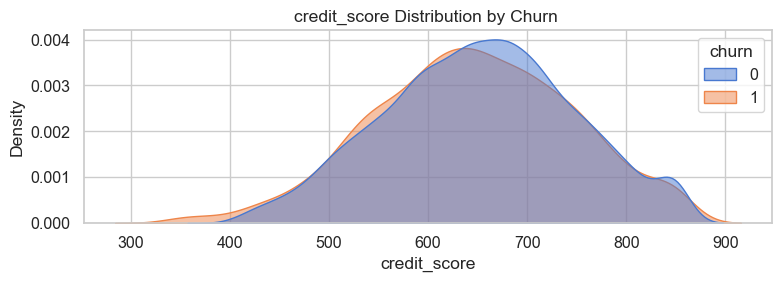

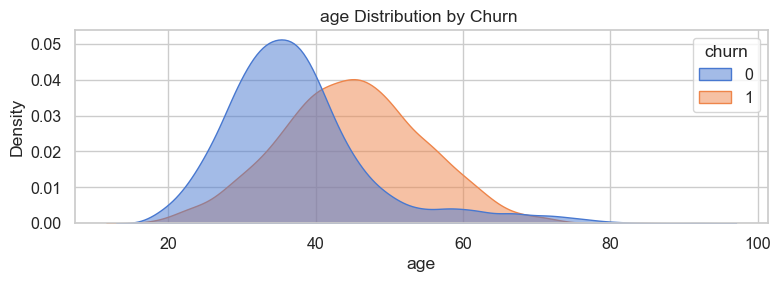

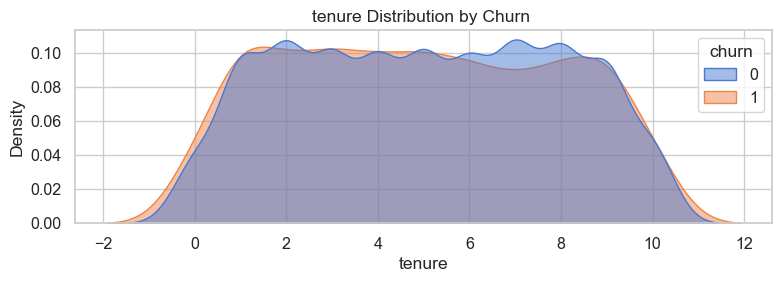

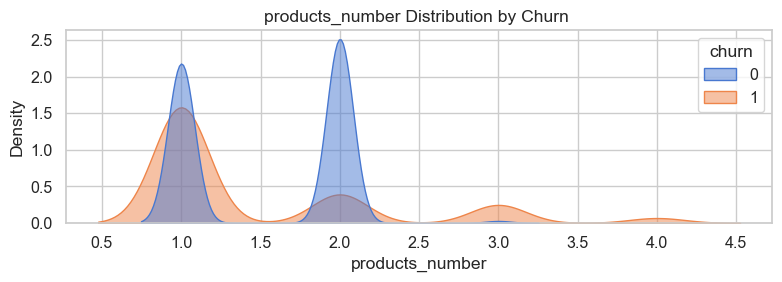

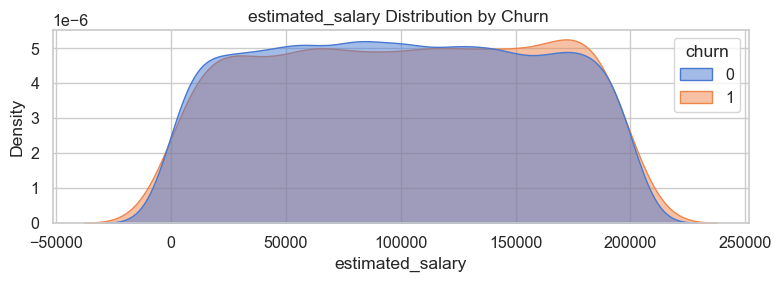

In [5]:
# Exploratory Data Analysis (visualisation)

# Check the actual column names in your dataframe
# Assuming the correct column name is 'products_number' instead of 'product_number'
num_cols = ['credit_score', 'age', 'tenure', 'products_number', 'estimated_salary']

#--- Distribution plots
for col in num_cols:
    # Add error handling to skip columns that don't exist
    if col in df.columns:
        plt.figure(figsize=(8,3))
        sns.kdeplot(data=df, x=col, hue='churn', fill=True, common_norm=False, alpha=0.5)
        plt.title(f'{col} Distribution by Churn ')
        plt.tight_layout()
        plt.show()
    else:
        print(f"Column '{col}' not found in the dataframe. Skipping this plot.")

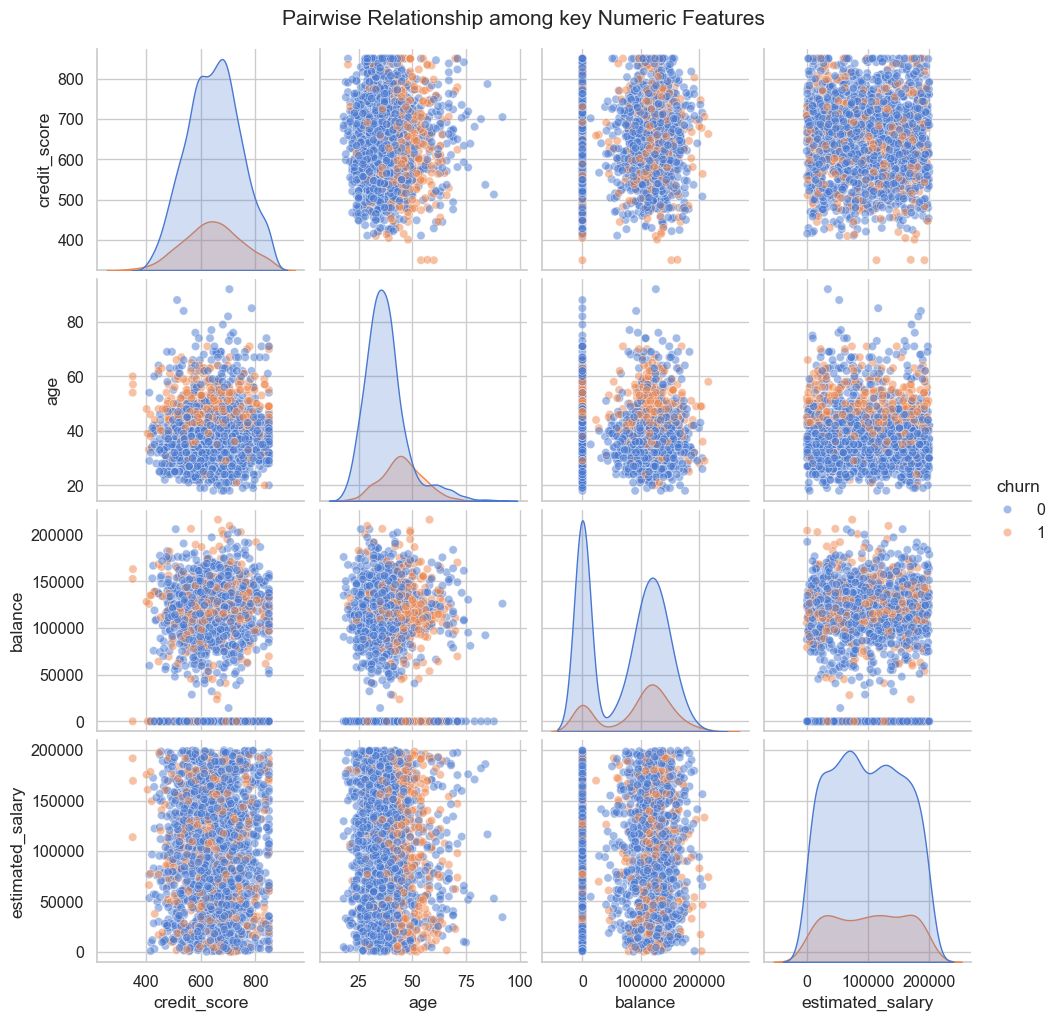

In [7]:
#  PAIRPLOT (SAMPLE FOR SPEED)

sns.pairplot(df.sample(frac=0.2, random_state=42),
             vars=['credit_score', 'age', 'balance', 'estimated_salary'],
             hue='churn', diag_kind='kde', plot_kws={'alpha':0.5})
plt.suptitle('Pairwise Relationship among key Numeric Features', y=1.02)
plt.show()

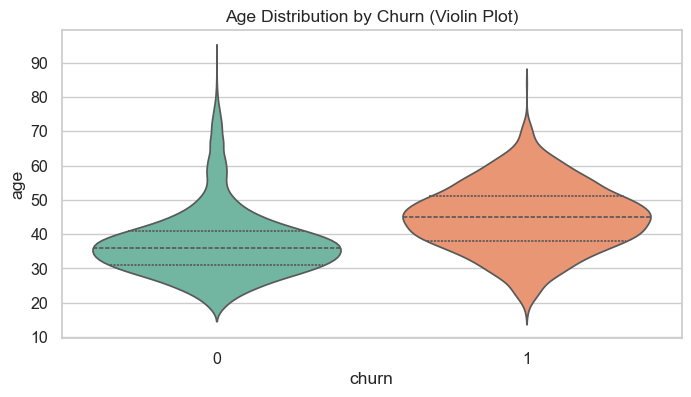

In [8]:
# --- Violin plot for Age 
plt.figure(figsize=(8,4))
sns.violinplot(data=df, x='churn', y='age', inner='quart', palette='Set2')
plt.title('Age Distribution by Churn (Violin Plot)')
plt.show()

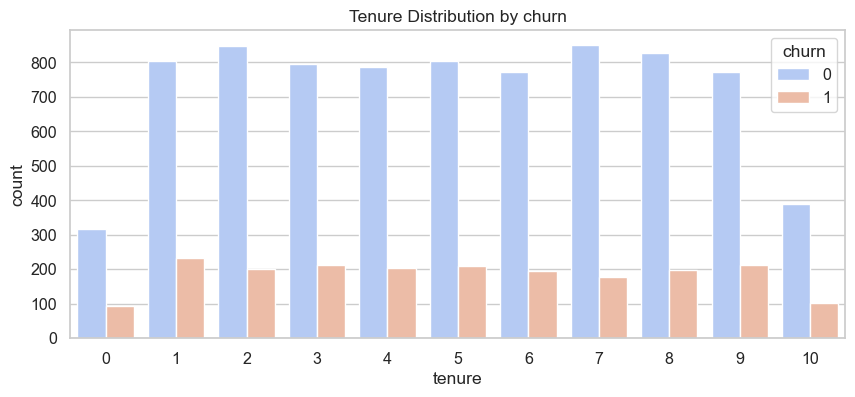

In [9]:
# --- Tenure distribution

plt.figure(figsize=(10,4))
sns.countplot(data=df, x='tenure', hue='churn', palette='coolwarm')
plt.title('Tenure Distribution by churn')
plt.show()


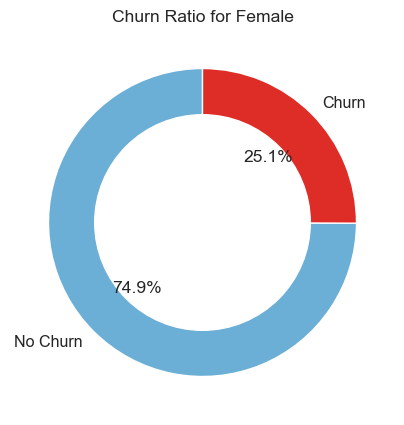

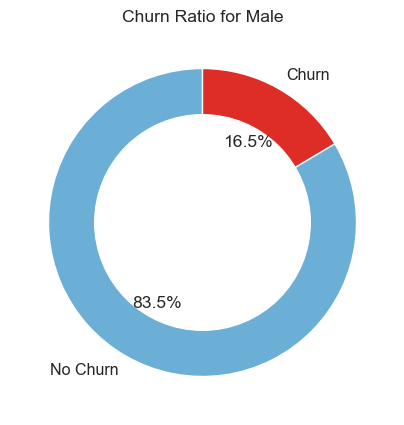

In [10]:
# Gender vs Churn Donut chart

gender_counts = df.groupby('gender')['churn'].value_counts(normalize=True).unstack().fillna(0)
for gender in gender_counts.index:
    plt.figure(figsize=(5,5))
    plt.pie(gender_counts.loc[gender], labels=['No Churn', 'Churn'],
            autopct='%1.1f%%' , startangle=90, colors=['#6baed6' ,'#de2d26'])
    center = plt.Circle((0,0),0.70, fc='white')
    fig = plt.gcf()
    fig.gca().add_artist(center)
    plt.title(f'Churn Ratio for {gender}')
    plt.show()
    

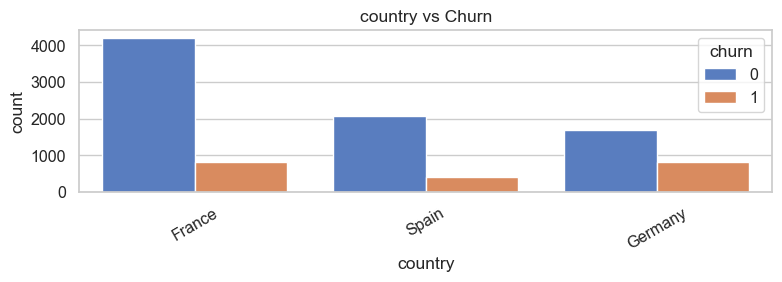

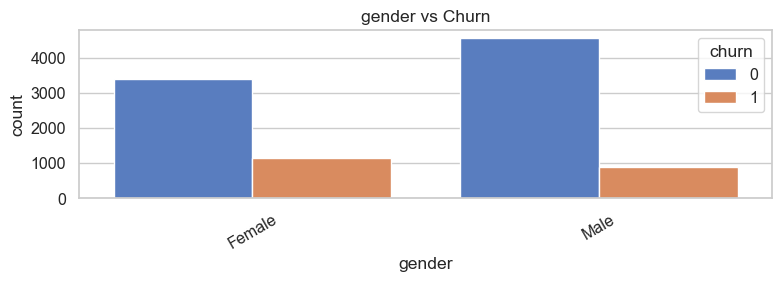

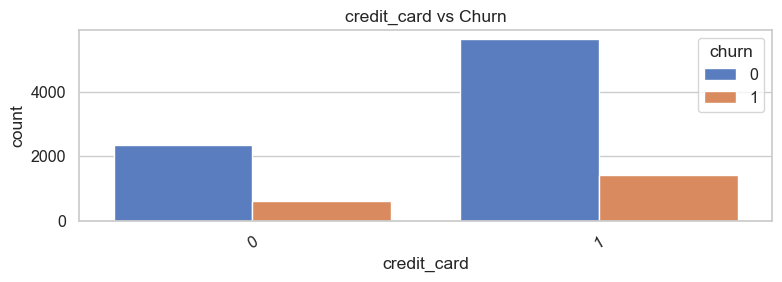

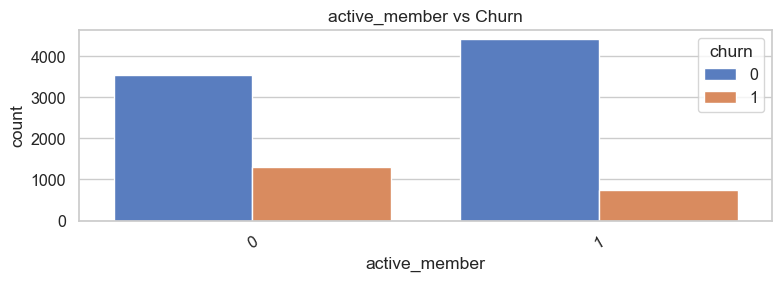

In [11]:
# CATEGORICL FEATURES

cat_cols = ['country', 'gender', 'credit_card', 'active_member']
for c in cat_cols:
    plt.figure(figsize=(8,3))
    sns.countplot(data=df, x=c, hue='churn')
    plt.title(f'{c} vs Churn')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

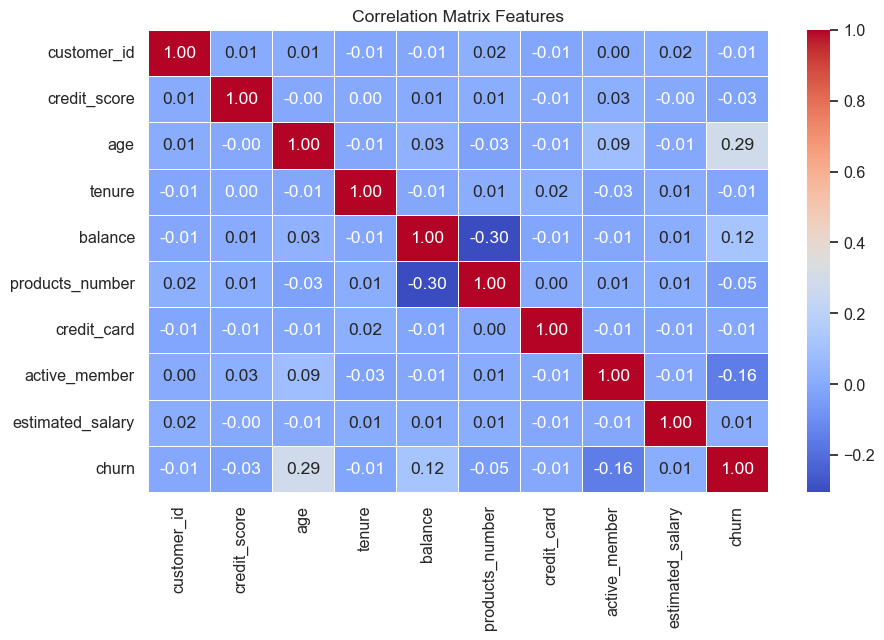

In [12]:
# HEATMAP VISUALIZATION 
# First, create the correlation matrix from your dataframe
# Assuming you have a dataframe called 'df' with your data

# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Calculate correlation matrix from numeric columns only
corr = numeric_df.corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidth=0.5)
plt.title('Correlation Matrix Features')
plt.show()

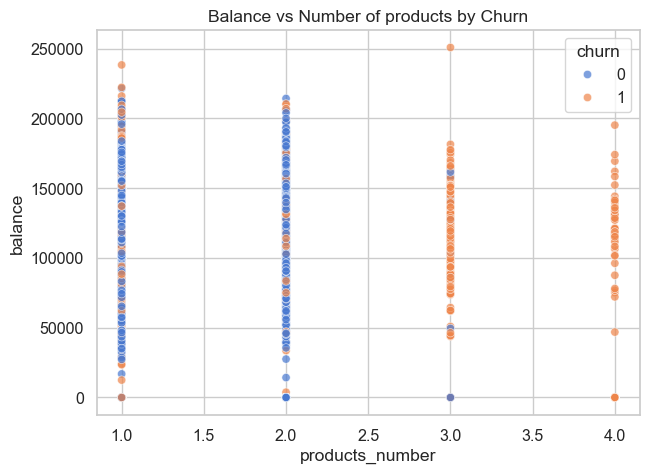

In [13]:
# BALANCE VS PRODUCT SCATTER

plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x='products_number', y='balance' , hue='churn', alpha=0.7)
plt.title('Balance vs Number of products by Churn')
plt.show()

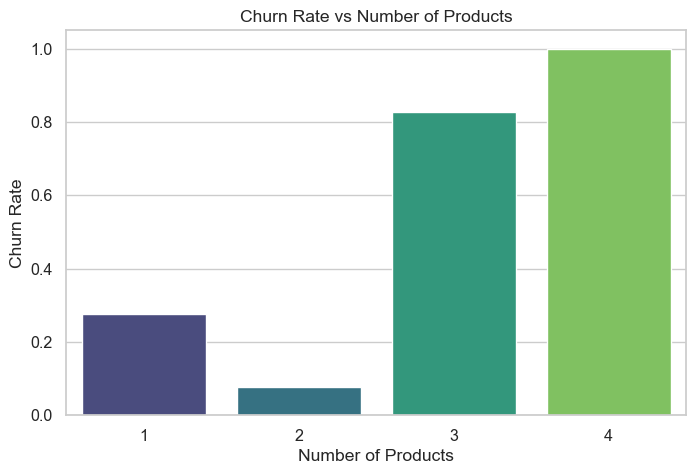

In [14]:
# --- Aggregate churn rate per number of products
churn_rate = df.groupby('products_number')['churn'].mean().reset_index()

# Plot churn rate
plt.figure(figsize=(8,5))
sns.barplot(data=churn_rate, x='products_number', y='churn', palette='viridis')
plt.xlabel('Number of Products')
plt.ylabel('Churn Rate')
plt.title('Churn Rate vs Number of Products')
plt.show()

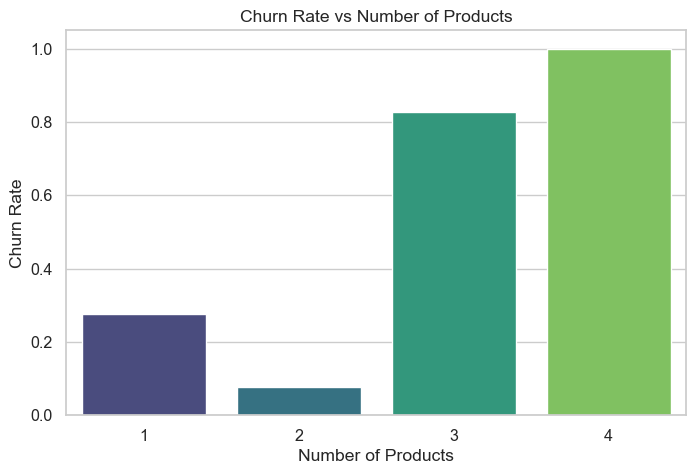

In [15]:
# --- Aggregate churn rate per number of products
churn_rate = df.groupby('products_number')['churn'].mean().reset_index()

# Plot churn rate
plt.figure(figsize=(8,5))
sns.barplot(data=churn_rate, x='products_number', y='churn', palette='viridis')
plt.xlabel('Number of Products')
plt.ylabel('Churn Rate')
plt.title('Churn Rate vs Number of Products')
plt.show()

In [16]:
# First, we need to define the df_fe DataFrame
# Assuming you have a CSV file or need to create sample data:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Create a sample DataFrame (replace this with your actual data loading code)
# For example: df_fe = pd.read_csv('your_data.csv')
# Or create sample data:
np.random.seed(42)
df_fe = pd.DataFrame({
    'customer_id': range(1000, 1100),
    'churn': np.random.choice([0, 1], size=100),
    'credit_score': np.random.randint(300, 850, size=100),
    'age': np.random.randint(18, 95, size=100),
    'tenure': np.random.randint(0, 10, size=100),
    'balance': np.random.uniform(0, 250000, size=100),
    'products_number': np.random.randint(1, 5, size=100),
    'estimated_salary': np.random.uniform(30000, 200000, size=100),
    'country': np.random.choice(['France', 'Spain', 'Germany'], size=100),
    'gender': np.random.choice(['Male', 'Female'], size=100),
    'credit_card': np.random.choice([0, 1], size=100),
    'active_member': np.random.choice([0, 1], size=100)
})

# Create derived features
df_fe['balance_per_product'] = df_fe['balance'] / df_fe['products_number']
df_fe['salary_balance_ratio'] = df_fe['estimated_salary'] / (df_fe['balance'] + 1)  # Adding 1 to avoid division by zero
df_fe['age_group'] = pd.cut(df_fe['age'], bins=[0, 30, 45, 60, 100], labels=['Young', 'Middle', 'Senior', 'Elderly'])
df_fe['tenure_bucket'] = pd.cut(df_fe['tenure'], bins=[0, 2, 5, 10], labels=['New', 'Regular', 'Loyal'])
df_fe['high_balance'] = (df_fe['balance'] > df_fe['balance'].median()).astype(int)

# Define features and target
target = 'churn'
drop_cols = ['customer_id']
features = [c for c in df_fe.columns if c not in [target] + drop_cols]

numeric_features = ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'estimated_salary',
                     'balance_per_product', 'salary_balance_ratio']
categorical_features = ['country', 'gender', 'credit_card', 'active_member', 'age_group', 'tenure_bucket', 'high_balance']

df_fe[categorical_features] = df_fe[categorical_features].astype('object')

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

print('Numeric features:', numeric_features)
print('Categorical features:', categorical_features)

Numeric features: ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'estimated_salary', 'balance_per_product', 'salary_balance_ratio']
Categorical features: ['country', 'gender', 'credit_card', 'active_member', 'age_group', 'tenure_bucket', 'high_balance']


In [17]:
X = df_fe[features]
y = df_fe[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print('Train shape:', X_train.shape, 'Test shape:', X_test.shape)
print('Train churn proportion:', y_train.mean(), 'Test churn proportion:', y_test.mean())

Train shape: (80, 15) Test shape: (20, 15)
Train churn proportion: 0.5625 Test churn proportion: 0.55


In [18]:
models = {
    'LogisticRegression': LogisticRegression(max_iter=500),
    'RandomForest': RandomForestClassifier(n_estimators=200, random_state=42),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=200, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=200, random_state=42),
    'SVC': SVC(probability=True, random_state=42)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor),
                           ('classifier', model)])
    
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    results[name] = scores
    print(f"{name} AUC: Mean={scores.mean():.4f} Std={scores.std():.4f}")

LogisticRegression AUC: Mean=0.6635 Std=0.0991
RandomForest AUC: Mean=0.4937 Std=0.1258
GradientBoosting AUC: Mean=0.5810 Std=0.1304
AdaBoost AUC: Mean=0.5746 Std=0.0944
SVC AUC: Mean=0.6413 Std=0.1296


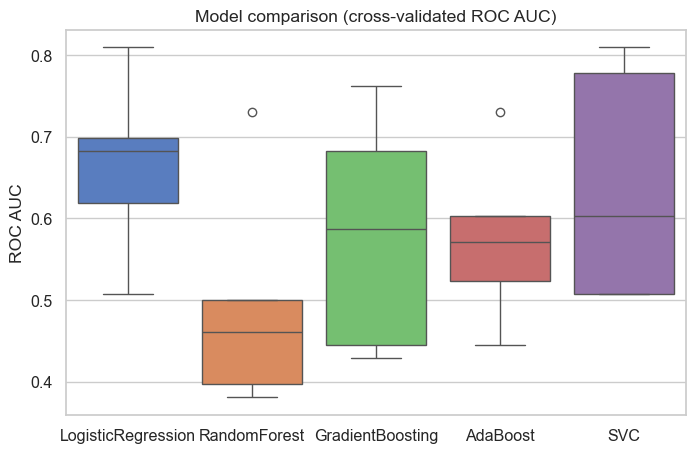

In [19]:
# Boxplot of CV AUC scores
plt.figure(figsize=(8,5))
sns.boxplot(data=[results[m] for m in list(results.keys())])
plt.xticks(ticks=range(len(results)), labels=list(results.keys()))
plt.ylabel('ROC AUC')
plt.title('Model comparison (cross-validated ROC AUC)')
plt.show()

In [20]:
# Choose best model (automatic pick by mean AUC)
best_name = max(results.keys(), key=lambda k: results[k].mean())
best_name, results[best_name].mean()

('LogisticRegression', np.float64(0.6634920634920635))

Test Accuracy: 0.5000
Test Precision: 0.5556
Test Recall: 0.4545
Test F1-score: 0.5000
Test ROC AUC: 0.5354

Classification Report:
              precision    recall  f1-score   support

           0       0.45      0.56      0.50         9
           1       0.56      0.45      0.50        11

    accuracy                           0.50        20
   macro avg       0.51      0.51      0.50        20
weighted avg       0.51      0.50      0.50        20



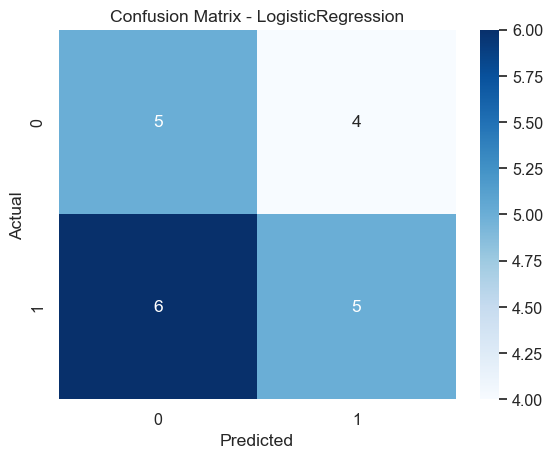

In [21]:
best_model = models[best_name]
best_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                ('classifier', best_model)])
best_pipeline.fit(X_train, y_train)

# Predictions
y_pred = best_pipeline.predict(X_test)
y_proba = best_pipeline.predict_proba(X_test)[::,1]

# Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_proba)

print(f'Test Accuracy: {acc:.4f}')
print(f'Test Precision: {prec:.4f}')
print(f'Test Recall: {rec:.4f}')
print(f'Test F1-score: {f1:.4f}')
print(f'Test ROC AUC: {roc:.4f}')

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - {best_name}')
plt.show()

In [22]:
if hasattr(best_pipeline.named_steps['classifier'], 'feature_importances_'):
    num_feats = numeric_features
    cat_feats = list(best_pipeline.named_steps['preprocessor'].transformers_[1][1].named_steps['onehot'].get_feature_names())
    feature_names = num_feats + cat_feats
    importances = best_pipeline.named_steps['classifier'].feature_importances_
    fi = pd.Series(importances, index=feature_names).sort_values(ascending=False)[:20]
    display(fi)
    plt.figure(figsize=(8,6))
    sns.barplot(x=fi.values, y=fi.index)
    plt.title('Top 20 Feature Importances')
    plt.show()
else:
    print('Selected model does not provide feature_importances_ attribute.')

Selected model does not provide feature_importances_ attribute.


In [23]:

sample = {
    'customer_id': 373292028,
    'credit_score': 650,
    'country': 'France',
    'gender': 'Male',
    'age': 40,
    'tenure': 3,
    'balance': 50000.0,
    'products_number': 2,
    'credit_card': 1,
    'active_member': 1,
    'estimated_salary': 60000.0
}

sample_df = pd.DataFrame([sample])

# --- Apply same feature engineering ---
sample_df['balance_per_product'] = sample_df['balance'] / (sample_df['products_number'].replace(0, np.nan))
sample_df['balance_per_product'].fillna(0, inplace=True)

sample_df['salary_balance_ratio'] = sample_df['estimated_salary'] / (sample_df['balance'].replace(0, np.nan))
sample_df['salary_balance_ratio'].replace([np.inf, -np.inf], np.nan, inplace=True)
sample_df['salary_balance_ratio'].fillna(sample_df['salary_balance_ratio'].median(), inplace=True)

bins = [0, 25, 35, 45, 55, 65, 100]
labels = ['<25', '25-34', '35-44', '45-54', '55-64', '65+']
sample_df['age_group'] = pd.cut(sample_df['age'], bins=bins, labels=labels)

sample_df['tenure_bucket'] = pd.cut(sample_df['tenure'], bins=[-1, 0, 2, 5, 10, 100], labels=['0', '1-2', '3-5', '6-10', '10+'])
sample_df['high_balance'] = (sample_df['balance'] > 50000.0).astype(int)  # can use 75th percentile of training set

# --- Drop ID ---
sample_df = sample_df.drop(columns=['customer_id'])

# --- Predict ---

In [24]:
# --- New customer sample ---
sample = {
    'customer_id': 373292028,
    'credit_score': 650,
    'country': 'France',
    'gender': 'Male',
    'age': 40,
    'tenure': 3,
    'balance': 50000.0,
    'products_number': 2,
    'credit_card': 1,
    'active_member': 1,
    'estimated_salary': 60000.0
}

sample_df = pd.DataFrame([sample])

# --- Apply same feature engineering ---
sample_df['balance_per_product'] = sample_df['balance'] / (sample_df['products_number'].replace(0, np.nan))
sample_df['balance_per_product'].fillna(0, inplace=True)

sample_df['salary_balance_ratio'] = sample_df['estimated_salary'] / (sample_df['balance'].replace(0, np.nan))
sample_df['salary_balance_ratio'].replace([np.inf, -np.inf], np.nan, inplace=True)
sample_df['salary_balance_ratio'].fillna(sample_df['salary_balance_ratio'].median(), inplace=True)

bins = [0, 25, 35, 45, 55, 65, 100]
labels = ['<25', '25-34', '35-44', '45-54', '55-64', '65+']
sample_df['age_group'] = pd.cut(sample_df['age'], bins=bins, labels=labels)

sample_df['tenure_bucket'] = pd.cut(sample_df['tenure'], bins=[-1, 0, 2, 5, 10, 100], labels=['0', '1-2', '3-5', '6-10', '10+'])
sample_df['high_balance'] = (sample_df['balance'] > 50000.0).astype(int)  # can use 75th percentile of training set

# --- Drop ID ---
sample_df = sample_df.drop(columns=['customer_id'])

# --- Predict ---

In [32]:
# Don't run streamlit commands directly in Python code
# Instead, use one of these approaches:

# Option 1: Use the subprocess module if you need to launch streamlit from Python
import subprocess
subprocess.Popen(["streamlit", "run", "app.py"])

# Option 2: Use the magic command if you're in Jupyter notebook
# !streamlit run app.py

# Note: The best practice is to run streamlit commands directly in your terminal:
# $ streamlit run app.py

<Popen: returncode: None args: ['streamlit', 'run', 'app.py']>